In [3]:
import numpy as np
import sympy as sp

In [4]:
def calculo_calidad(valor_propiedad_actual : float, propiedad_estado_f : float, propiedad_estado_g : float) -> float :
    """
    EXERGIA-CODE : https://github.com/NiengLee/termodinamica_general/blob/main/funciones_termodinamica.ipynb
    
    Permite calcular la calidad de una sustancia en estado de saturación:
    
    Datos de entrada:
    - valor_propiedad_actual : el valor de la propiedad intermedia entre estado f y g a condiciones dadas de T y P.
    - propiedad_estado_f : el valor de la propiedad en el estado de líquido saturado a T y P dadas.
    - propiedad_estado_g : el valor de la propiedad en el estado de vapor saturado a T y P dadas.
    
    Retorna:
    - x_calidad : porcentaje de vapor en la mezcla de vapor y líquido en etapa de saturación. 
    
    """
    propiedad_gf = propiedad_estado_g - propiedad_estado_f
    x_calidad = (valor_propiedad_actual-propiedad_estado_f) / propiedad_gf
    return x_calidad

def valor_propiedad_saturacion(x_calidad : float, propiedad_estado_f : float, propiedad_estado_g : float):
    """
    EXERGIA-CODE : https://github.com/NiengLee/termodinamica_general/blob/main/funciones_termodinamica.ipynb
    
    Permite calcular la calidad de una sustancia en estado de saturación:
    
    Datos de entrada:
    - x_calidad : porcentaje de vapor en la mezcla de vapor y líquido en etapa de saturación. 
    - propiedad_estado_f : el valor de la propiedad en el estado de líquido saturado a T y P dadas.
    - propiedad_estado_g : el valor de la propiedad en el estado de vapor saturado a T y P dadas.
    
    Retorna:
    - valor_propiedad_x : el valor de la propiedad intermedia entre estado f y g a condiciones dadas de T y P.
    
    """
    valor_propiedad_x = propiedad_estado_f + x_calidad * (propiedad_estado_g-propiedad_estado_f)
    return valor_propiedad_x

def resultado_interpolacion(x_busqueda, x_inicial, y_inicial, x_final, y_final):
    """
    EXERGIA-CODE : https://github.com/NiengLee/termodinamica_general/blob/main/funciones_termodinamica.ipynb
    
    Permite calcular una propiedad intermedia entre datos tabulados de propiedades termodinámicas
    
    Datos de entrada:
    - x_busqueda : valor de la variable independiente para el cual se desea estimar la propiedad (por ejemplo T o P).
    - x_inicial : valor inferior conocido de la variable independiente.
    - y_inicial : valor de la propiedad correspondiente a x_inicial.
    - x_final : valor superior conocido de la variable independiente.
    - y_final : valor de la propiedad correspondiente a x_final.
    
    Retorna:
    - valor_propiedad_x : el valor de la propiedad intermedia entre estado f y g a condiciones dadas de T y P.
    
    """
    m = (y_final-y_inicial)/(x_final-x_inicial)
    resultado = m*(x_busqueda-x_inicial) + y_inicial
    return resultado

def delta_h_wark(
    T_inicial : float,
    T_final : float,
    a : float,
    b : float,
    c : float,
    d : float,
    e : float,
    PM : float
) -> dict:
    """
    EXERGIA-CODE : https://github.com/NiengLee/termodinamica_general/blob/main/funciones_termodinamica.ipynb
    
    Tomado como referencia : Libro de termodinamica de Kenneth wark página 929. ver constantes aquí : https://github.com/NiengLee/termodinamica_general/blob/main/capitulo4.ipynb, sección "Expresiones para capacidades caloríficas" 
    
    Permite calcular el cambio de entalpía a partir de la función de capacidad calorífica en función de la temperatura.
    
    Datos de entrada:
    - T_i : temperatura en el estado inicial (K).
    - T_f : temperatura en el estado final (K).
    - a, b, c, d, e : constantes de el polinomio de Cp tomado de referencia bibliógraficas
    - PM : peso molecular de la sustancia que se va analizar (kg/kmol).
    
    Retorna:
    - delta_h : Cambio de entalpía entre la temperatura final e inicial (kJ/kmol o kJ/kg).
    
    """
    R_gas = 8.3145
    
    if PM <= 0:
        raise ValueError("PM debe ser > 0 (kg/kmol).")

    if T_inicial == T_final:
        return {
            "delta_h_kJ_kmol": 0.0,
            "delta_h_kJ_kg": 0.0
        }

    def F(T):
        return (a*T + b*T**2 / 2 + c*T**3 / 3 + d*T**4 / 4 + e*T**5 / 5) * R_gas

    delta_h_kJ_kmol = F(T_final) - F(T_inicial)
    delta_h_kJ_kg = delta_h_kJ_kmol / PM

    return {
        "delta_h_kJ_kmol": delta_h_kJ_kmol,
        "delta_h_kJ_kg": delta_h_kJ_kg
    }
    
def delta_h_cengel(
    T_inicial : float,
    T_final : float,
    a : float,
    b : float,
    c : float,
    d : float,
    PM : float
) -> dict : 
    """
        EXERGIA-CODE : https://github.com/NiengLee/termodinamica_general/blob/main/funciones_termodinamica.ipynb
        
        Tomado como referencia : Libro de termodinamica de Cenges Yunus página 901. ver constantes aquí : https://github.com/NiengLee/termodinamica_general/blob/main/capitulo4.ipynb, sección "Expresiones para capacidades caloríficas" 
        
        Permite calcular el cambio de entalpía a partir de la función de capacidad calorífica en función de la temperatura.
        
        Datos de entrada:
        - T_inicial : temperatura en el estado inicial (K).
        - T_final : temperatura en el estado final (K).
        - a, b, c, d : constantes de el polinomio de Cp tomado de referencia bibliógraficas
        - PM : peso molecular de la sustancia que se va analizar (kg/kmol).
        
        Retorna:
        - delta_h : cambio de entalpía de la sustancia entre temperatura final e inicial (kJ/kg o kJ/kmol).    
    """
    
    if PM <= 0:
        raise ValueError("PM debe ser > 0 (kg/kmol).")

    if T_inicial == T_final:
        return {
            "delta_h_kJ_kmol": 0.0,
            "delta_h_kJ_kg": 0.0
        }

    def F(T):
        return (a*T+ b*T**2 / 2+ c*T**3 / 3+ d*T**4 / 4)

    delta_h_kJ_kmol = F(T_final) - F(T_inicial)
    delta_h_kJ_kg = delta_h_kJ_kmol / PM

    return {
        "delta_h_kJ_kmol": delta_h_kJ_kmol,
        "delta_h_kJ_kg": delta_h_kJ_kg
    }

# Pagina 225 , 10 - Kenneth Wark

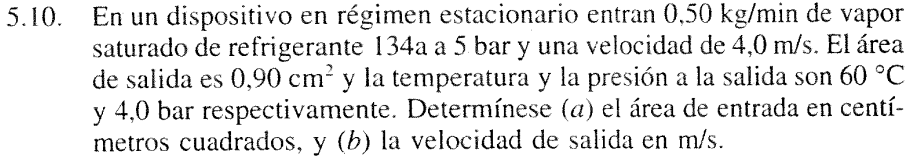

In [5]:
print(f"Realizado por Exergia Code : ")
#   Condiciones iniciales - Vapor saturado R134 - A
m_in = 0.5 * (1/60)      # kg/s
P_in = 5 * (100000)      # Pa
vel_in = 4               # m/s

#   Condiciones finales
A_out = 0.9 * (1/(100**2)) # m²
T_out = 60 + 273.15        # K
P_out = 4 * (100000)       # Pa 

#   Desarrollo - régimen estacionario

#   Objetivos : A_in [=] cm² ; vel_out [=] m/s
vesp_in = 0.0409 # m³ / kg
A_in = (vesp_in * m_in) / vel_in
A_in_cm2 = A_in * ((100**2))
print(f"El area de entrada es {A_in_cm2:,.4f} cm²")

vesp_out = 0.06405 # m³ / kg
vel_out = (A_in * vel_in * vesp_out) / (vesp_in * A_out)
print(f"La velocidad de salida es {vel_out:,.4f} m/s")

Realizado por Exergia Code : 
El area de entrada es 0.8521 cm²
La velocidad de salida es 5.9306 m/s


# Pagina 252 ,10 - Çengel Yunus

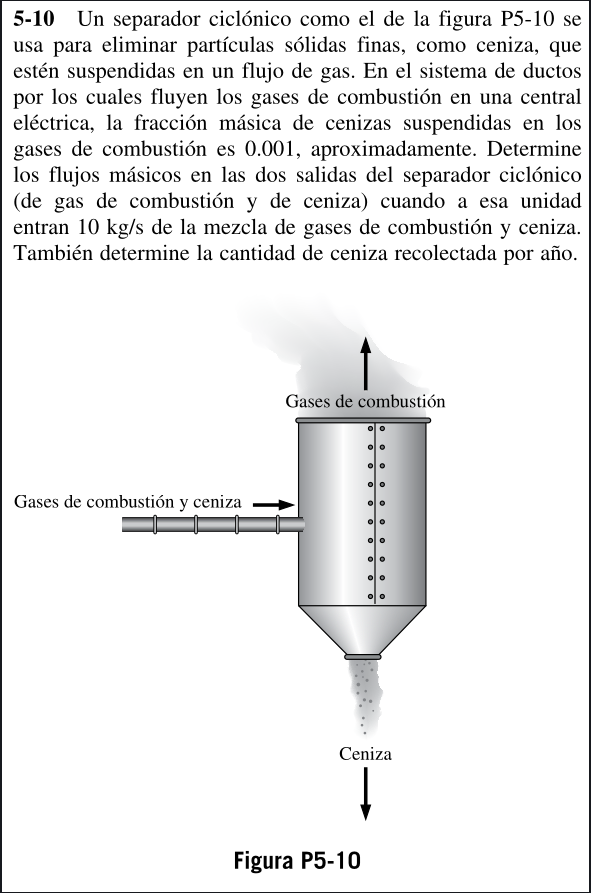

In [6]:
print(f"Realizado por Exergia Code : ")
#   Condiciones iniciales - Vapor saturado R134 - A
x_masica_cenizas_gases_combustion = 1/1000
masa_total_in = 10          # kg / s
#   Desarrollo - régimen estacionario

#   Objetivos : flujos masicos de salida [=] m/s ; ceniza recolectada en el año
m_cenizas_out = masa_total_in * x_masica_cenizas_gases_combustion
m_gases_com_out = masa_total_in - m_cenizas_out

print(f"el flujo masico, para la salidad de gases de combustión es {m_gases_com_out:,.4f} kg/s")
print(f"el flujo masico, para la salidad cenizas {m_cenizas_out:,.4f} kg/s")

m_cenizas_año = m_cenizas_out * (60*60*24*365)

print(f"La cantidad de cenizas generadas en un año por el proceso es {m_cenizas_año:,.1f} kg")
print(f"La cantidad de cenizas generadas en un año por el proceso es {m_cenizas_año/1000:,.1f} Ton")

Realizado por Exergia Code : 
el flujo masico, para la salidad de gases de combustión es 9.9900 kg/s
el flujo masico, para la salidad cenizas 0.0100 kg/s
La cantidad de cenizas generadas en un año por el proceso es 315,360.0 kg
La cantidad de cenizas generadas en un año por el proceso es 315.4 Ton


# Pagina 228 , 36 - Kenneth Wark

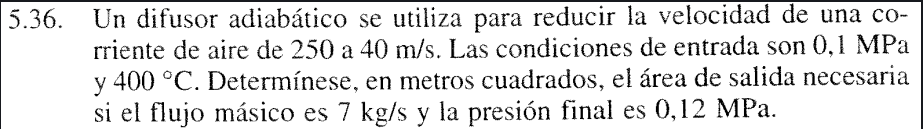

In [7]:
print(f"Realizado por Exergia Code : ")
#   Condiciones iniciales
vel_in = 250            # m / s
P_in = 0.1 * (1000)     # kPa ; 0.1 mPa ; 1 bar     
T_in = 400 + 273.15     # K

#   Condiciones finales
vel_out = 40            # m / s
P_out = 0.12 * (1000)   # kPa ; 0.12 MPa , 1.2 bar 

#   Desarrollo
m_dot = 7               # kg / s
Q_transf = 0
PM_aire = 28.97
R_gas = 8.3145 / (PM_aire)    # kPa . m³ / kg . K

#   Objetivos : A_out [=] m²
print(f"la temperatura a la entrada del difusor es {T_in:,.4f} K")

T_1 = 670 # K
T_2 = 683 # K
h_1 = 681.14 # kJ/kg
h_2 = 691.82 # kJ/kg

h_in = resultado_interpolacion(T_in , T_1, T_2, h_1, h_2)
print(f"el valor de la entalpía en la entrada del difusor es {h_in:,.4f} kJ/kg")
delta_ec = (((vel_in**2)-(vel_out**2))/2) / 1000 # kJ/kg

h_out = h_in + delta_ec
print(f"el valor de la entalpía a la salida del difusor es {h_out:,.4f} kJ/kg")

T_1 = 710 # K
T_2 = 720 # K
h_1 = 724.04 # kJ/kg
h_2 = 734.82 # kJ/kg

T_out = resultado_interpolacion(h_out, h_1, h_2, T_1, T_2)
print(f"la temperatura a la salida del difusor es {T_out:,.4f} K")

vesp_out = (R_gas * T_out) / P_out
A_out = (m_dot * vesp_out) / vel_out

print(f"el area de salida del difusor es {A_out:,.6f} m²")

Realizado por Exergia Code : 
la temperatura a la entrada del difusor es 673.1500 K
el valor de la entalpía en la entrada del difusor es 685.4940 kJ/kg
el valor de la entalpía a la salida del difusor es 715.9440 kJ/kg
la temperatura a la salida del difusor es 726.2742 K
el area de salida del difusor es 0.303980 m²


# Pagina 254, 30 - Çengel Yunus

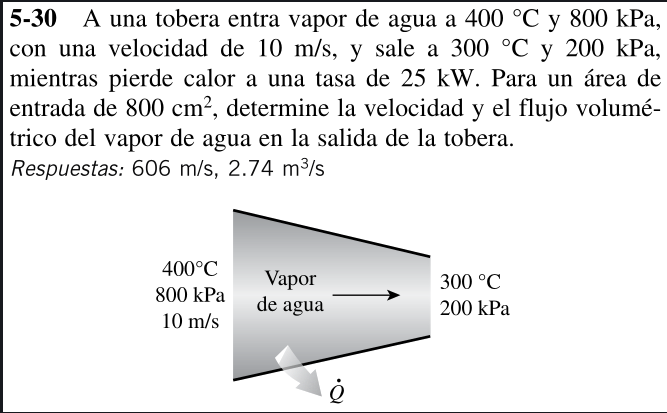

In [8]:
print(f"Realizado por Exergia Code : ")
#   Condiciones iniciales - vapor de agua
T_in = 400 + 273.15         # K
P_in = 800                  # kPa ; 0.8 MPa
vel_in = 10                 # m / s
A_in = 800 * (1/(100**2))  # m²

#   Condiciones finales
T_out = 300 + 273.15        # K
P_out = 200                 # kPa ; 0.2 MPa

#   Desarrollo
Q_out = 25                  # kJ / s

#   Objetivos  : vel_out [=] m/s ; caudal_out [=] m³ / s
h_in = 3267.7 # kJ /kg
h_out = 3072.1 # kJ /kg
vesp_in = 0.38429 # m³ /kg
vesp_out = 1.31623 # m³ /kg

m_dot = (vel_in * A_in) / vesp_in 
print(f"el flujo másico es {m_dot:,.4f} kg/s")

delta_h = (h_out - h_in) * (1000)
q_out = (Q_out / m_dot) * (1000)

vel_out_2_2 = ((vel_in**2)/2) + ( -delta_h - q_out)
vel_out = np.sqrt(vel_out_2_2 * 2)

print(f"la velocidad del fluido a la salida es {vel_out:,.4f} m/s")

caudal_out = m_dot * vesp_out

print(f"caudal a la salida es {caudal_out:,.4f} m³/s")


Realizado por Exergia Code : 
el flujo másico es 2.0818 kg/s
la velocidad del fluido a la salida es 606.0378 m/s
caudal a la salida es 2.7401 m³/s


# Pagina 231 , 62 - Kenneth Wark

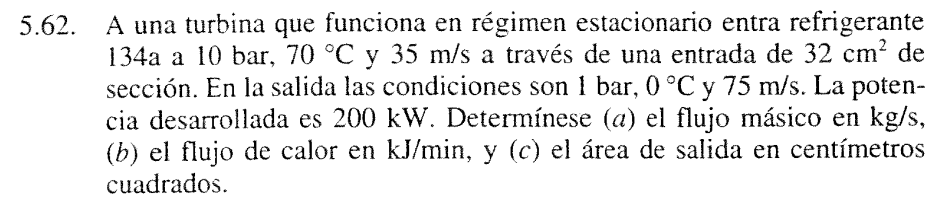

In [9]:
print(f"Realizado por Exergia Code : ")
#   Condiciones iniciales - R134-a - reg estacionario
P_in = 10           # bar
T_in = 70 + 273.15  # K
vel_in = 35         # m/s
A_in = 32 * (1/(100**2))    # m²

#   Condiciones finales
P_out = 1           # bar
T_out = 0 + 273.15  # K
vel_out = 75        # m/s

#   Desarrollo
W_out = 200         # kJ / s

#   Objetivos : m_dot [=] kg / s ; Q [=] kJ/min ; A_out [=] cm²
vesp_in = 0.02423 # m³/kg
h_in = 302.34     # kJ/kg
vesp_out = 0.21587 # m³/kg
h_out = 252.99    # kJ/kg

m_dot = (A_in * vel_in) / vesp_in

print(f"el flujo másico es {m_dot:,.4f} kg/s") 

A_out = (m_dot * vesp_out) / vel_out

print(f"el Area a la salida de flujo es {A_out:,.4f} m²") 
print(f"el Area a la salida de flujo es {A_out*(100**2) :,.4f} cm²")

delta_h = h_out - h_in
delta_Ec = (((vel_out**2)-(vel_in**2))/2) / 1000

Q_transf = m_dot * (delta_h + delta_Ec) + W_out

print(f"la transferencia de calor es {Q_transf:,.4f} kJ/s")
print(f"la transferencia de calor es {Q_transf*60:,.4f} kJ/min")

Realizado por Exergia Code : 
el flujo másico es 4.6224 kg/s
el Area a la salida de flujo es 0.0133 m²
el Area a la salida de flujo es 133.0441 cm²
la transferencia de calor es -17.9447 kJ/s
la transferencia de calor es -1,076.6818 kJ/min


# Página 255 , 46 - Çengel Yunus

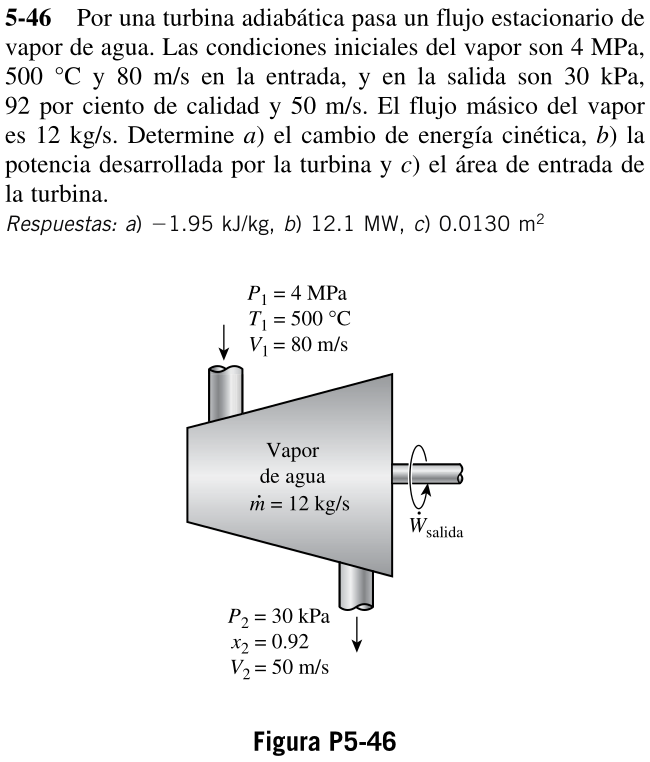

In [10]:
print(f"Realizado por Exergia Code : ")
#   Condiciones iniciales
Pin = 4 * (1000000)         # Pa
Tin = 500 + 273.15          # K
vel_in = 80                  # m / s

#   Condiciones finales - saturación
Pout = 30 * (1000)          # kPa
x = 92/100
vel_out = 50                 # m/s

#   Desarrollo - adiabatico, flujo estacionario, vapor de agua
m_dot = 12                   # kg/s

#   Objetivo : delta_Ec [=] kJ/kg ; W_generado [=] MW ; Ain [=] m²

h_in = 3446 # kJ/kg
vesp_in = 0.08644 # m³/kg

h_f = 289.27 # kJ/kg
h_g = 2624.6 # kJ/kg
vesp_f = 0.001022 # m³/kg
vesp_g = 5.2287 # m³/kg

h_out = valor_propiedad_saturacion(x, h_f, h_g)
vesp_out = valor_propiedad_saturacion(x, vesp_f, vesp_g)

delta_Ec = (((vel_out**2)-(vel_in**2)) / 2) / 1000 # kJ/kg
delta_h = h_out - h_in
W_out = m_dot * (delta_h + delta_Ec)

print(f"El cambio de energía cinética es {delta_Ec:,.4f} kJ/kg")
print(f"La potencia generada es {W_out:,.4f} kW")
print(f"La potencia generada es {W_out/1000:,.4f} MW")

A_in = (m_dot * vesp_in)/ vel_in
print(f"El area de flujo en la entrada de la turbina es {A_in:,.4f} m²")


Realizado por Exergia Code : 
El cambio de energía cinética es -1.9500 kJ/kg
La potencia generada es -12,122.1168 kW
La potencia generada es -12.1221 MW
El area de flujo en la entrada de la turbina es 0.0130 m²


# Pagina 234 , 86 - Kenneth Wark

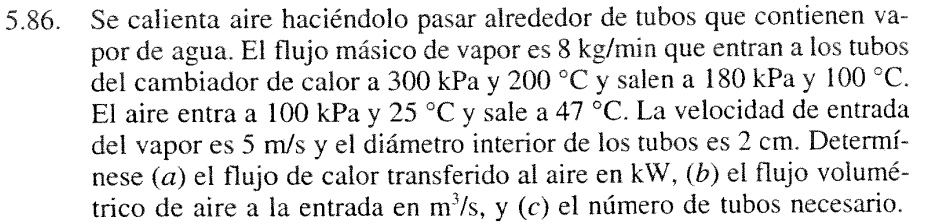

In [11]:
print(f"Realizado por Exergia Code : ")
#   aire - calentamiento
P_in_air = 100          # kPa
T_in_air = 25 + 273.15  # K

T_out_air = 47 + 273.15 # K
PM_aire = 28.97         # kg/kmol

Cp_a = 3.653
Cp_b = -1.334e-3
Cp_c = 3.291e-6
Cp_d = -1.910e-9
Cp_e = 0.275e-12

R_gas = 8.3145  # kPa . m³ / kmol . K
#   agua - enfriamiento
m_dot_agua = 8 * (1/60)  # kg / s
P_in_agua = 300          # kPa ; 3 bar
T_in_agua = 200 + 273.15 # K
vel_in_agua = 5          # m / s 

P_out_agua = 180         # kPa ; 1.8 bar
T_out_agua = 100 + 273.15 # K

D_agua = 2 * (1/100)     # m 
#   Desarrollo

#   Objetivos : Q_transferido [=] kW ; caudal_aire [=] m³ / s ; número tubos

h_in_agua = 2865.5 # kJ/kg
vesp_in_agua = 0.716 # m³ / kg
h_out_agua = 419.04 # kJ/kg

Q_rechazado_agua = m_dot_agua * (h_out_agua - h_in_agua)
print(f"el calor rechazado del agua y recibido por el aire es {Q_rechazado_agua:,.4f} kJ/s")

delta_h_aire = delta_h_wark(
    T_in_air,
    T_out_air,
    Cp_a,
    Cp_b,
    Cp_c,
    Cp_d,
    Cp_e,
    PM_aire
)

Q_recibido_aire = -Q_rechazado_agua
m_dot_aire = Q_recibido_aire/delta_h_aire["delta_h_kJ_kg"]

print(f"el flujo másico es : {m_dot_aire:,.4f} kg / s")
vesp_in_aire = (R_gas * T_in_air) / P_in_air 
vesp_in_aire = vesp_in_aire * (1/PM_aire)
caudal_in_air = m_dot_aire * vesp_in_aire

print(f"el caudal de aire en la entrada del intercambiador es : {caudal_in_air:,.4f} m³ / s")

A_total_in_agua = (vesp_in_agua * m_dot_agua) / vel_in_agua
A_1_tuberia = np.pi * ((D_agua/2)**2)
numero_tuberias = A_total_in_agua / A_1_tuberia

print(f"el numero de tuberías necsarias son : {numero_tuberias:,.4f}")


Realizado por Exergia Code : 
el calor rechazado del agua y recibido por el aire es -326.1947 kJ/s
el flujo másico es : 14.7550 kg / s
el caudal de aire en la entrada del intercambiador es : 12.6259 m³ / s
el numero de tuberías necsarias son : 60.7760


# Página 255 , 50 - Çengel Yunus

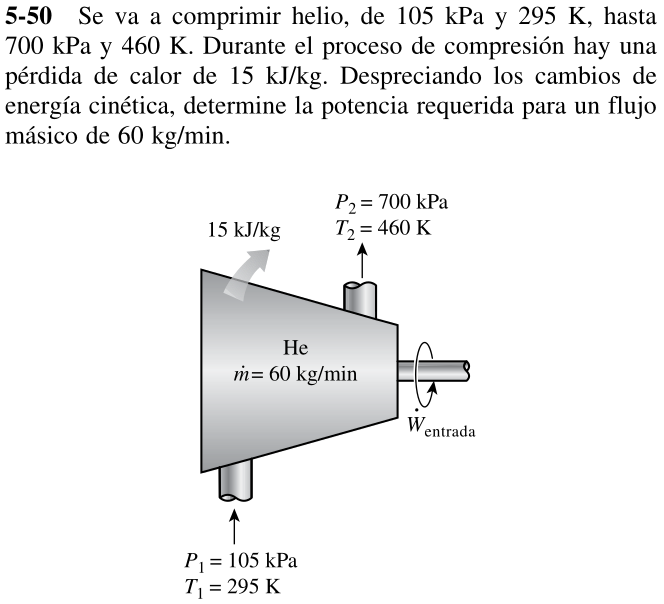

In [12]:
print(f"Realizado por Exergia Code : ")
#   Condiciones iniciales : 
P_in = 105           # kPa
T_in = 295           # K

#   Condiciones finales : 
P_out = 700          # kPa
T_out = 460          # K

#   Desarrollo
q_out = 15          # kJ / kg
m_dot = 60 * (1/60) # kg / s
Cp = 5.1926         # kJ/ kg.K

#   Objetivos : W_in
delta_T = T_out - T_in
W_in = m_dot * ((Cp * (delta_T)) + (q_out))

print(f"La potencia requerida para la operación del compresor es {W_in:,.4f} kJ/s")

Realizado por Exergia Code : 
La potencia requerida para la operación del compresor es 871.7790 kJ/s


# Pagina 236 ,105 - Kenneth Wark

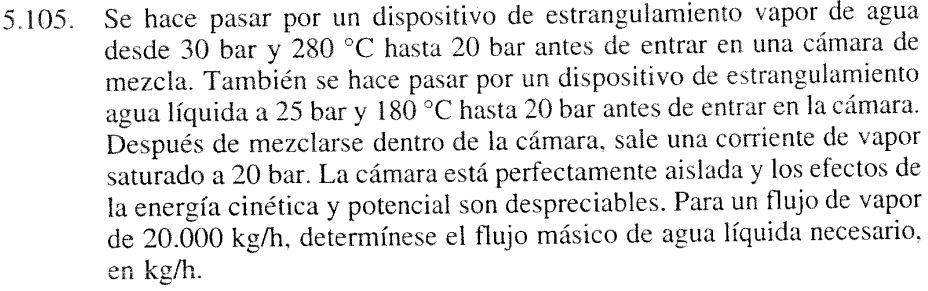

In [13]:
print(f"Realizado por Exergia Code : ")
#   Condiciones entrada - vapor de agua - 1
P_in_vap_a_es = 30                      # bar
T_in_vap_a_es = 280 + 273.15            # K
P_in_vap_d_es = 20                      # bar
m_dot_1 = 20000 * (1/3600)              # kg / s

#   Condiciones entrada - Líquido comprimido - 2
P_in_liq_a_es = 25                      # bar
T_in_liq_a_es = 180 + 273.15            # K
P_in_liq_d_es = 20                      # bar

#   Condiciones salida - vapor saturado - 3
P_out = 20                              # bar

#   Objetivos : m_dot_liq [=] kg / h
h_in_vapor = 2941.3
h_in_liq = 763.97
h_out = 2799.5

m_liq = (m_dot_1 * ( h_out - h_in_vapor )) / (h_in_liq - h_out)

print(f"el flujo másico de la corriente de agua en estado de líquido comprimido es {m_liq:,.4f} kg /s")
print(f"el flujo másico de la corriente de agua en estado de líquido comprimido es {m_liq*3600:,.4f} kg /h")

Realizado por Exergia Code : 
el flujo másico de la corriente de agua en estado de líquido comprimido es 0.3870 kg /s
el flujo másico de la corriente de agua en estado de líquido comprimido es 1,393.2489 kg /h


# Pagina 256 , 55 - Çengel Yunus

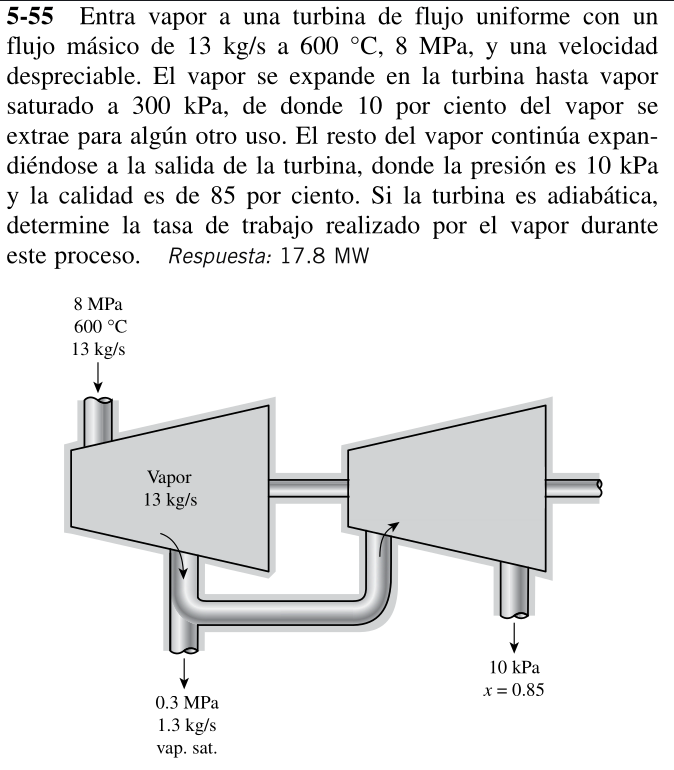

In [14]:
print(f"Realizado por Exergia Code : ")
#   Condiciones iniciales
m_dot_in_1 = 13               # kg / s
T_in_1 = 600 + 273.15       # K
P_in_1 = 8                  # MPa

#   Condiciones de salida turbina 1 - entrada turbina 2 - vapor saturado
P_out_1 = 300               # kPa
P_in_2 = P_out_1
porcent_1_out = 0.10
m_dot_in_2 = (1 - porcent_1_out) * m_dot_in_1

#   Condiciones de salida turbina 2 - estado de saturación
P_out_2 = 10                # kPa
x = 0.85

#   Objetivos : Wdot_out_total [=] MW
h1 = 3642.4
h2 = 2724.9
hf = 191.81
hg = 2583.9
h3 = valor_propiedad_saturacion(x, hf, hg)

W_generado_turbina_1 = - m_dot_in_1 * (h2 - h1)
W_generado_turbina_2 = - m_dot_in_2 * (h3 - h2)
W_generado_total = W_generado_turbina_1 + W_generado_turbina_2
W_generado_total_MW = W_generado_total / 1000 

print(f"la potencia total generada por la turbina es {W_generado_total_MW:,.1f} MW")

Realizado por Exergia Code : 
la potencia total generada por la turbina es 17.8 MW


# Página 238 , 114 - Kenneth Wark

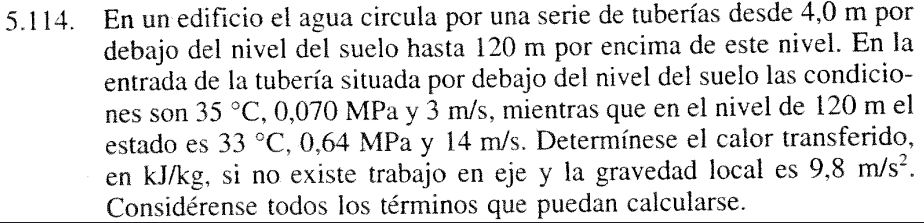

In [15]:
print(f"Realizado por Exergia Code : ")
#   Condiciones iniciales : 
long_tubo_bajo_suelo = 4        # m
P_in = 0.070                    # MPa 
T_in = 35 + 273.15              # K
vel_in = 3                      # m / s

#   Condiciones finales : 
long_tubo_sobre_suelo = 120     # m
P_out = 0.64                    # MPa
T_out = 33 + 273.15             # K
vel_out = 14                    # m / s

#   Desarrollo
g = 9.8                         # m / s²

#   Objetivos : Q_transferido [=] kJ / kg
h1 = 146.68
h2 = 138.33
delta_h = h2 - h1
delta_Ec = (((vel_out**2)-(vel_in**2))/2) / 1000
delta_Ep = (g * (long_tubo_sobre_suelo + long_tubo_bajo_suelo)) / 1000

q = delta_h + delta_Ec + delta_Ep

print(f"el calor transferido es {q:,.4f} kJ / kg")

Realizado por Exergia Code : 
el calor transferido es -7.0413 kJ / kg


# Pagina 258 , 81 - Çengel Yunus

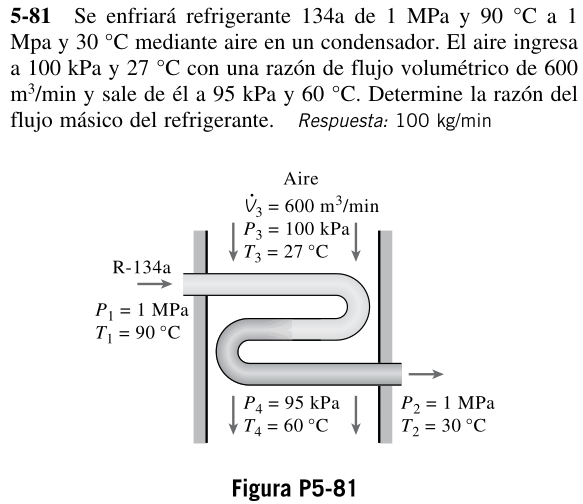

In [ ]:
print(f"Realizado por Exergia Code : ")
#   R134a
P_in_r134a = 1              # MPa
T_in_r134a = 90 + 273.15    # K
P_out_r134a = 1             # MPa
T_out_r134a = 30 + 273.15   # K

#   Aire
P_in_air = 100              # kPa
T_in_air = 27 + 273.15      # K
P_out_air = 95              # kPa
T_out_air = 60 + 273.15     # K

caudal_air = 600 * (1/60)           # m³ / s
PM_aire = 28.97             # kg / kmol
R_gas = 8.3145              # kPa . m³ / kmol . K

Cp_a = 28.11
Cp_b = 0.1967e-2
Cp_c = 0.4802e-5
Cp_d = -1.966e-9

#   Objetivos : m_dot [=] kg / min

delta_h_air = delta_h_cengel(
    T_in_air,
    T_out_air,
    Cp_a,
    Cp_b,
    Cp_c,
    Cp_d,
    PM_aire
) 

delta_h_air_2 = 1.005 * (T_out_air-T_in_air)

vesp_in_air = (R_gas * T_in_air) / (PM_aire * P_in_air)
Q_recibido_air = (caudal_air * delta_h_air["delta_h_kJ_kg"]) / (vesp_in_air)
#Q_recibido_air = (caudal_air * delta_h_air_2) / (vesp_in_air)
print(f"calor recibido = {Q_recibido_air:,.4f} kJ/s")

Q_rechazado_r134a = - Q_recibido_air
h_in_r134a = 324.66 # kJ/kg
h_out_r134a = 107.34 # kJ/kg
delta_h_r134a = h_out_r134a - h_in_r134a

m_dot_r134a = Q_rechazado_r134a / delta_h_r134a
print(f"flujo masico r134a = {m_dot_r134a:,.4f} kg/s")
print(f"flujo masico r134a = {m_dot_r134a*60:,.4f} kg/min")

Realizado por Exergia Code : 
calor recibido = 385.4877 kJ/s
flujo masico r134a = 1.7738 kg/s
flujo masico r134a = 106.4295 kg/min


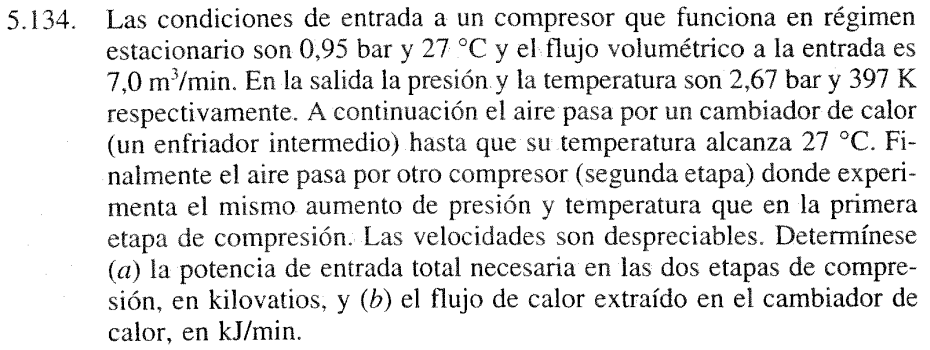

In [18]:
#   Condiciones entrada compresor 1 - aire : 
P1 = 0.95 * (100) # kPa
T1 = 27 + 273.15  # K
caudal1 = 7 * (1/60) # m³ / min

#   Condiciones salida compresor 1 - entrada intercambiador : 
P2 = 2.67 * (100) # kPa
T2 = 397  # K

#   Condiciones salida intercambiador de calor - entrada compresor 2 :
T3 = 27 + 273.15 # K

#   Condiciones salida compresor 2 :
T4 = T2
P4 = P2

PM_aire = 28.97         # kg/kmol
R_gas = 8.3145  # kPa . m³ / kmol . K
Cp_a = 3.653
Cp_b = -1.334e-3
Cp_c = 3.291e-6
Cp_d = -1.910e-9
Cp_e = 0.275e-12


#   Objetivos : 
m_dot = (caudal1 * P1 * PM_aire)/(R_gas * T1)

delta_h_compresor_1 = delta_h_wark(
    T1,
    T2,
    Cp_a,
    Cp_b,
    Cp_c,
    Cp_d,
    Cp_e,
    PM_aire
)

W_compresor1 = m_dot * (delta_h_compresor_1["delta_h_kJ_kg"])
print(f"{W_compresor1:,.4f}")

delta_h_intercambiador = delta_h_wark(
    T2,
    T3,
    Cp_a,
    Cp_b,
    Cp_c,
    Cp_d,
    Cp_e,
    PM_aire
)

Q_rechazado = - m_dot * (delta_h_intercambiador["delta_h_kJ_kg"])
print(f"{Q_rechazado:,.4f}")
print(f"{(Q_rechazado) * 60:,.4f}")

delta_h_compresor_2 = delta_h_wark(
    T3,
    T4,
    Cp_a,
    Cp_b,
    Cp_c,
    Cp_d,
    Cp_e,
    PM_aire
)

W_compresor2 = m_dot * delta_h_compresor_2["delta_h_kJ_kg"]
print(f"{W_compresor2:,.4f}")


12.5606
12.5606
753.6381
12.5606


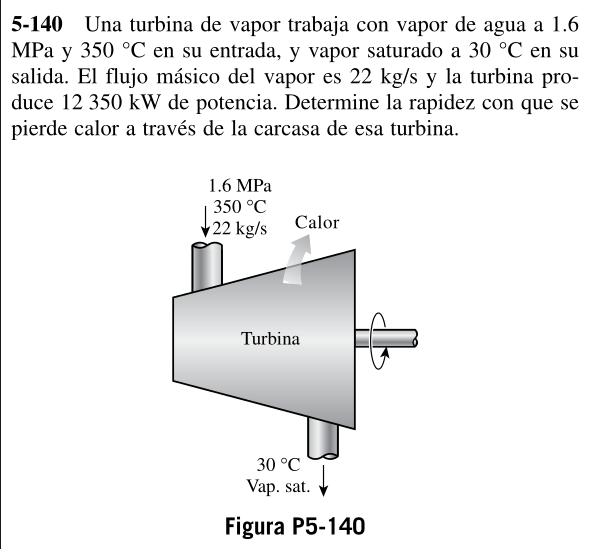

In [19]:
#   Condiciones entrada : 
P_in = 1.6          # MPa
T_in = 350 + 273.15 # K  
m_dot = 22          # kg / s
    
#   Condiciones salida :
T_out = 30 + 273.15 # K

#   Desarrollo : 
W_generado = 12350  # kJ / s

#   Objetivos : 
h_in = 3146.0   # kJ / kg
h_out = 2555.6  # kJ / kg

Q_out = m_dot * (h_in - h_out) - W_generado
print(f"{Q_out:,.4f} kJ/s")

638.8000 kJ/s
